## 1. Setup

In [ ]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)

## 2. Load Cleveland Dataset

In [ ]:
# https://drive.google.com/file/d/1U02zDTnnSG2Xf_YINxs-FqfR7UbdjeNI/view
!gdown 1U02zDTnnSG2Xf_YINxs-FqfR7UbdjeNI

Downloading...
From: https://drive.google.com/uc?id=1U02zDTnnSG2Xf_YINxs-FqfR7UbdjeNI
To: /content/[Data]-cleveland.csv
100% 10.9k/10.9k [00:00<00:00, 19.8MB/s]


In [ ]:
COLUMNS = ['age','sex','cp','trestbps','chol','fbs','restecg',
           'thalach','exang','oldpeak','slope','ca','thal','target']

raw = pd.read_csv('[Data]-cleveland.csv', header=None)
raw.columns = COLUMNS

for c in ['age','trestbps','chol','thalach','oldpeak','ca','thal']:
    raw[c] = pd.to_numeric(raw[c], errors='coerce')

raw['target'] = (raw['target'] > 0).astype(int)

numeric_cols = ['age','trestbps','chol','thalach','oldpeak']
categorical_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal']

X_all = raw.drop(columns=['target'])
y_all = raw['target']

## 3. Preprocess and Split

In [ ]:
def build_preprocess():
    num_proc = Pipeline([('imputer', SimpleImputer(strategy='median')),
                         ('scaler', StandardScaler())])
    cat_proc = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                         ('scaler', MinMaxScaler())])
    return ColumnTransformer([
        ('num', num_proc, numeric_cols),
        ('cat', cat_proc, categorical_cols),
    ])

def split_8_1_1(X, y, seed):
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed)
    X_va, X_te, y_va, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=seed)
    return X_tr, X_va, X_te, y_tr, y_va, y_te

RF_PARAMS = dict(n_estimators=50, max_depth=5, max_features='sqrt',
                 n_jobs=-1, random_state=SEED)

## 4. Vary the Split Seed

In [ ]:
rows = []
for seed in range(10):
    X_tr, X_va, X_te, y_tr, y_va, y_te = split_8_1_1(X_all, y_all, seed)
    pipe = Pipeline([('preprocess', build_preprocess()),
                     ('rf', RandomForestClassifier(**RF_PARAMS))]).fit(X_tr, y_tr)
    rows.append({'seed': seed,
                 'val_acc': pipe.score(X_va, y_va),
                 'test_acc': pipe.score(X_te, y_te)})

df = pd.DataFrame(rows).set_index('seed').round(4)
display(df)

,val_acc,test_acc
seed,,
0,0.9000,0.8710
1,0.8000,0.8387
2,0.7000,0.9677
3,0.7667,0.9032
4,0.9667,0.8387
5,0.8000,0.8387
6,0.7667,0.8065
7,0.7667,0.8387
8,0.9000,0.8065


## 5. Spread of Test Accuracy

In [ ]:
acc = df['test_acc']
print(f"min={acc.min():.4f}  max={acc.max():.4f}  "
      f"mean={acc.mean():.4f}  std={acc.std():.4f}")
print(f"range={acc.max() - acc.min():.4f}")


min=0.7097  max=0.9677  mean=0.8419  std=0.0670
range=0.2580


## 6. Control: Vary the Model Seed

In [ ]:
X_tr, X_va, X_te, y_tr, y_va, y_te = split_8_1_1(X_all, y_all, SEED)

model_acc = []
for seed in range(10):
    pipe = Pipeline([
        ('preprocess', build_preprocess()),
        ('rf', RandomForestClassifier(**{**RF_PARAMS, 'random_state': seed}))
    ]).fit(X_tr, y_tr)
    model_acc.append(pipe.score(X_te, y_te))

model_acc = pd.Series(model_acc)
print(f"split seed -> range={acc.max() - acc.min():.4f}, std={acc.std():.4f}")
print(f"model seed -> range={model_acc.max() - model_acc.min():.4f}, "
      f"std={model_acc.std():.4f}")

split seed -> range=0.2580, std=0.0670
model seed -> range=0.0645, std=0.0215


## 7. Visualization

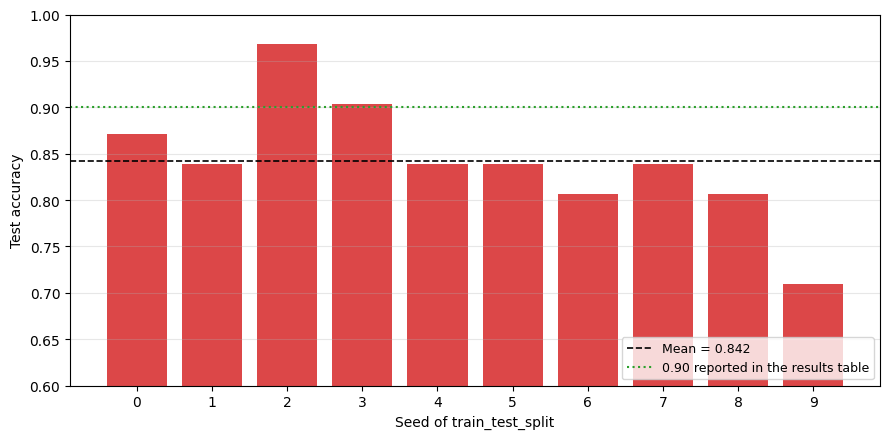

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(df.index, df['test_acc'], color='tab:red', alpha=0.85)
ax.axhline(acc.mean(), color='black', ls='--', lw=1.2,
           label=f'Mean = {acc.mean():.3f}')
ax.axhline(0.90, color='tab:green', ls=':', lw=1.5,
           label='0.90 reported in the results table')

ax.set_xlabel('Seed of train_test_split')
ax.set_ylabel('Test accuracy')
ax.set_xticks(df.index)
ax.set_ylim(0.6, 1.0)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()